<a href="https://colab.research.google.com/github/KutyshenkoYana/ITStep-AI/blob/superwised_learning/SL_HomeWork_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [4]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(4746, 12)
Posted On             object
BHK                  float64
Rent                 float64
Size                 float64
Floor                 object
Area Type             object
Area Locality         object
City                  object
Furnishing Status     object
Tenant Preferred      object
Bathroom             float64
Point of Contact      object
dtype: object
Posted On            367
BHK                  404
Rent                 377
Size                 344
Floor                366
Area Type            356
Area Locality        399
City                 358
Furnishing Status    351
Tenant Preferred     374
Bathroom             359
Point of Contact     374
dtype: int64


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

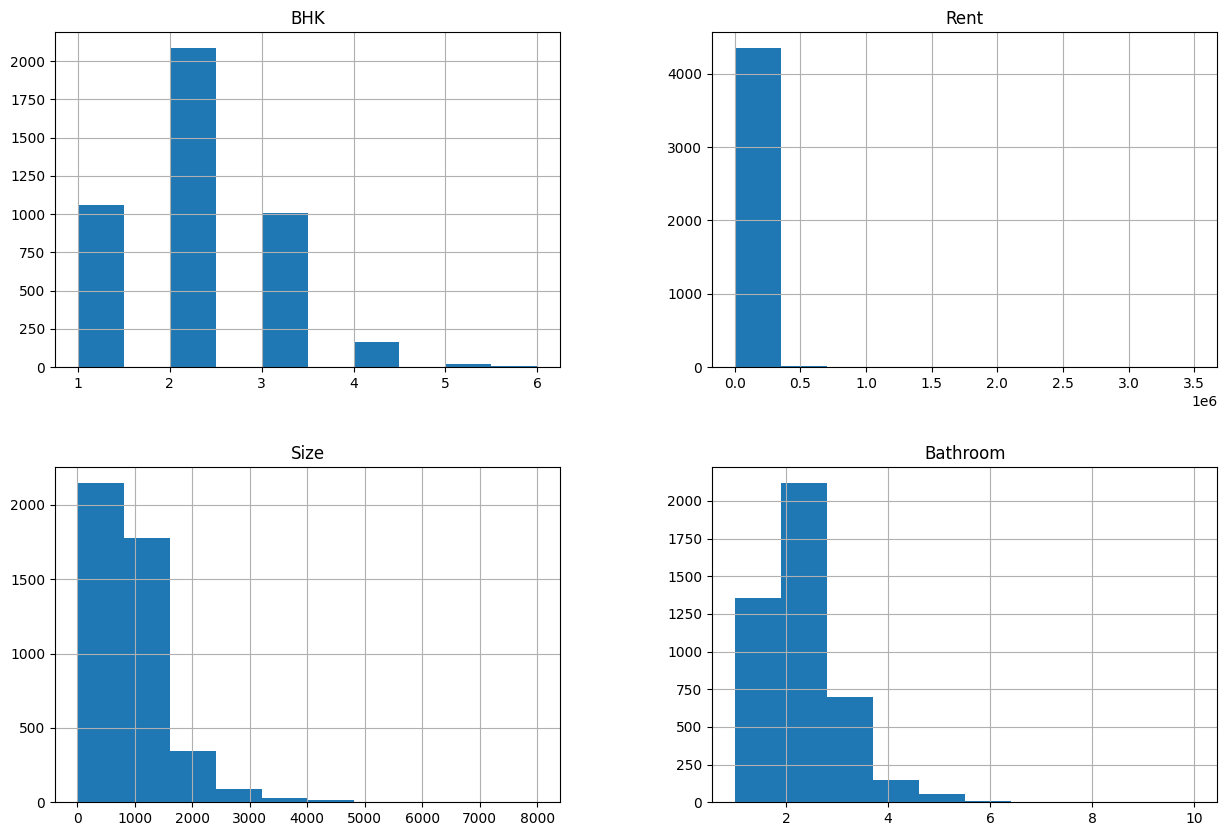

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10))
plt.show()

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

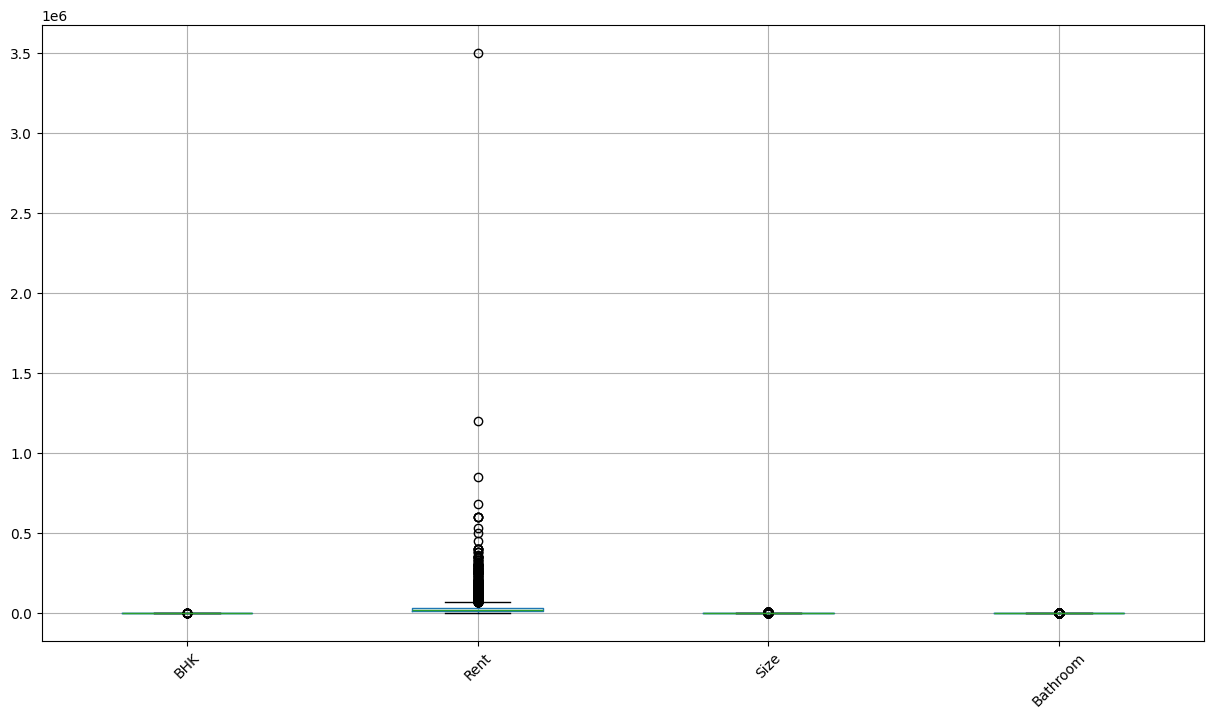

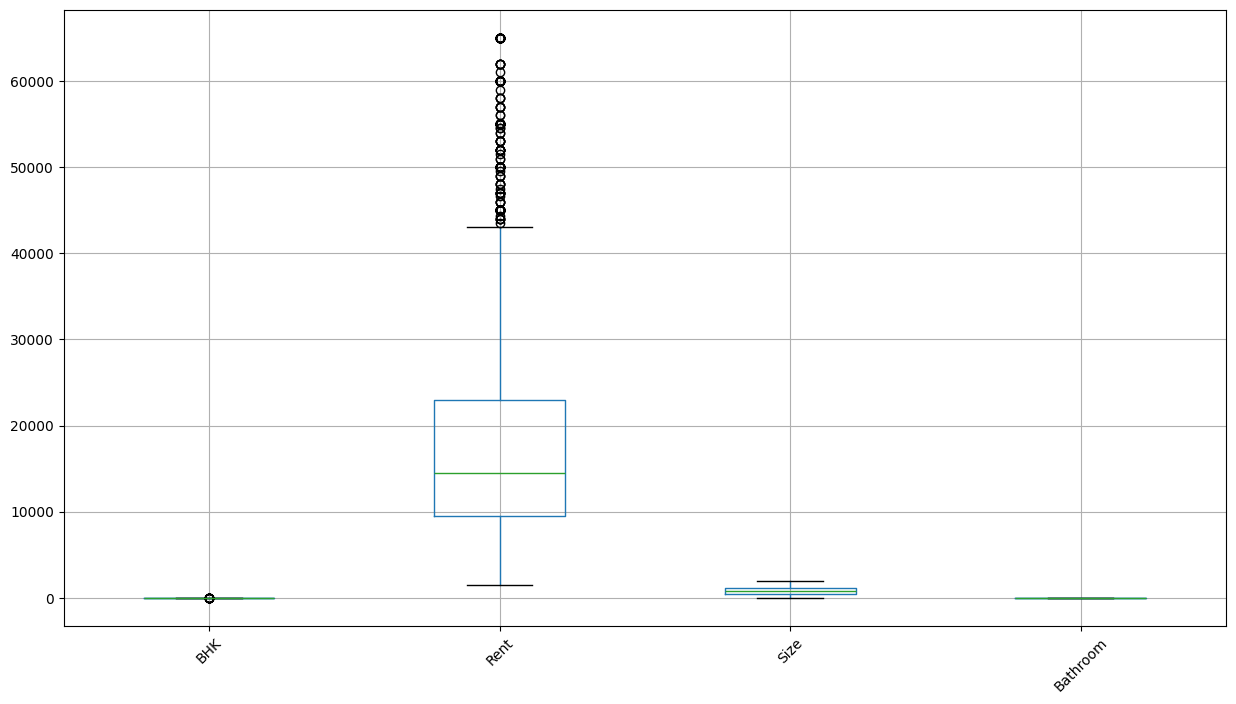

In [6]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns].boxplot(figsize=(15, 8))
plt.xticks(rotation=45)
plt.show()

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower) & (df[column] <= upper)]

df[numeric_columns].boxplot(figsize=(15, 8))
plt.xticks(rotation=45)
plt.show()

# Завдання 4
Створіть Pipeline для обробки даних

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_columns = df.select_dtypes(include="number").columns

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

df[numeric_columns] = pipeline.fit_transform(df[numeric_columns])

print(df)

       Posted On       BHK      Rent      Size            Floor    Area Type  \
0     2022-05-18  0.118881 -0.648366  0.664383  Ground out of 2          NaN   
1     2022-05-13  0.118881  0.105737 -0.067891       1 out of 3   Super Area   
2     2022-05-16  0.118881 -0.120494  0.420292       1 out of 3   Super Area   
3     2022-07-04  0.118881 -0.648366 -0.067891       1 out of 2   Super Area   
4            NaN  0.118881 -0.836892  0.054155       1 out of 2  Carpet Area   
...          ...       ...       ...       ...              ...          ...   
4738  2022-07-06  0.118881 -0.120494  0.066359       4 out of 5  Carpet Area   
4739  2022-07-06  0.118881  0.482789  0.517928       2 out of 4  Carpet Area   
4743  2022-07-10  1.566578  1.236892  2.250976       3 out of 5  Carpet Area   
4744  2022-07-06  1.566578  1.990995  1.640748     23 out of 34  Carpet Area   
4745  2022-05-04  0.118881 -0.271314  0.420292       4 out of 5  Carpet Area   

                     Area Locality     